# Read the data and plot to visualize


Read the data

In [1]:
# output : csv data
import os
import pandas as pd

for file in os.listdir("../data"):
    df = pd.read_parquet(f"../data/{file}")
    csv_file_name = file.replace(".parquet", ".csv")
    df.to_csv(f"csv_data/{csv_file_name}", index=False)

In [2]:
# returns dataset provided as dataframe
def lidar_data_df_func(dataset):
    lidar_data_df = pd.read_parquet(f"../data/{dataset}.parquet")
    return lidar_data_df
lidar_data_df_easy = lidar_data_df_func("lidar_cable_points_easy")
lidar_data_df_medium = lidar_data_df_func("lidar_cable_points_medium")
lidar_data_df_hard = lidar_data_df_func("lidar_cable_points_hard")
lidar_data_df_extrahard = lidar_data_df_func("lidar_cable_points_extrahard")
dataset_dic = {"easy": lidar_data_df_easy, "medium": lidar_data_df_medium, "hard": lidar_data_df_hard, "extrahard": lidar_data_df_extrahard}
for name, dataset in dataset_dic.items():
    print("\nDataset:", name)
    print(dataset.head())
    print(dataset.columns)
    print(dataset.shape)


Dataset: easy
              x          y          z
2211   6.196634 -13.157755  10.582272
2905 -10.440643  17.264460  10.926065
1411   2.977432  -3.552676  10.072814
251    5.924494 -10.974960  10.342501
794   -7.062873  12.850664  10.557997
Index(['x', 'y', 'z'], dtype='object')
(1502, 3)

Dataset: medium
             x          y          z
5117  8.927091 -17.271705   7.724551
3574 -0.514603   3.713301   6.604667
245   6.141806 -11.188338  10.438597
3258  6.998778 -10.146784   6.937106
5803 -7.537887  12.818930   7.195763
Index(['x', 'y', 'z'], dtype='object')
(2803, 3)

Dataset: hard
              x          y          z
2211   6.218581 -13.165374  10.530679
2905 -10.478510  17.248335  10.921316
1411   2.968935  -3.533002  10.008485
251    5.925292 -10.927853  10.407309
794   -7.029980  12.853360  10.579427
Index(['x', 'y', 'z'], dtype='object')
(601, 3)

Dataset: extrahard
              x          y          z
2211   6.037626 -13.231044  10.527397
2905 -10.721094  17.124476  10.94

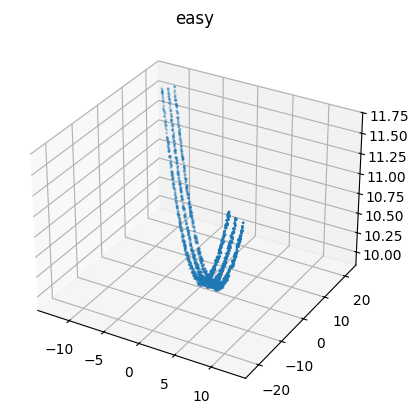

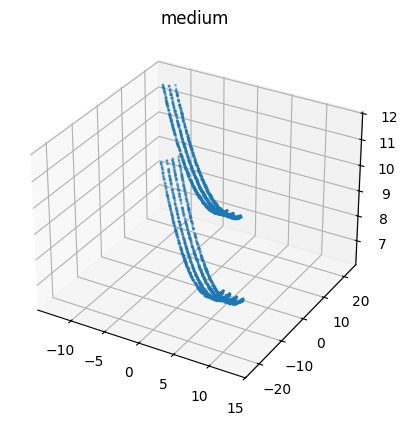

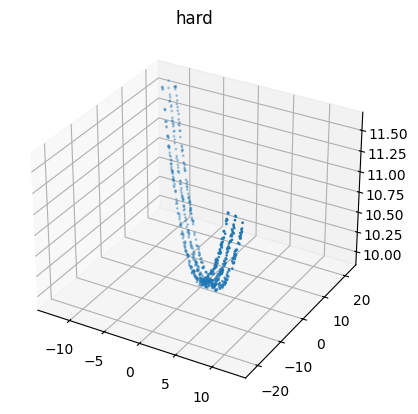

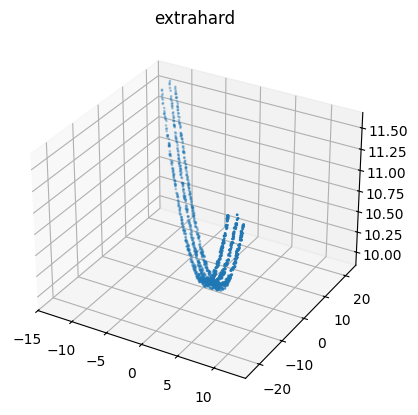

In [3]:
# looks like x, y, z are the column coordinates, check in graphical form
import matplotlib.pyplot as plt

for k,dataset in dataset_dic.items():
    # print(f"Plot for {k}")
    blank_canvas = plt.figure().add_subplot(111, projection="3d")
    blank_canvas.scatter(dataset["x"], dataset["y"], dataset["z"], s=1)
    blank_canvas.set_title(f"{k}")
    plt.savefig(f"images/vis_{k}.png")

In [4]:
# numpy array
coordinates = lidar_data_df_easy[["x", "y", "z"]].values
print(coordinates)

[[  6.19663435 -13.15775512  10.58227233]
 [-10.44064287  17.26446014  10.92606471]
 [  2.97743169  -3.55267568  10.0728142 ]
 ...
 [ -9.74456296  19.54896042  11.2729797 ]
 [ -2.06073546   5.73005863  10.09060331]
 [ 11.12628854 -18.49790267  11.07095826]]


# Easy - DBScan clustering

In [ ]:
# clustering and no. of clusters 
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5, 0.6, 0.7, 0.8, 0.9]
eps_list = [0.65, 0.7, 0.75, 0.8]
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.65, Unique clusters: {0, 1, 2}
For eps = 0.7, Unique clusters: {0, 1, 2}
For eps = 0.75, Unique clusters: {0, 1, 2}
For eps = 0.8, Unique clusters: {0}


In [21]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5, 0.6, 0.7, 0.8, 0.9]
eps_list = [0.76] #0.65, 0.7, 0.75, 0.75, 0.8
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.76, Unique clusters: {0, 1, 2}


For easy graph - eps value can be between 0.65 and 0.76

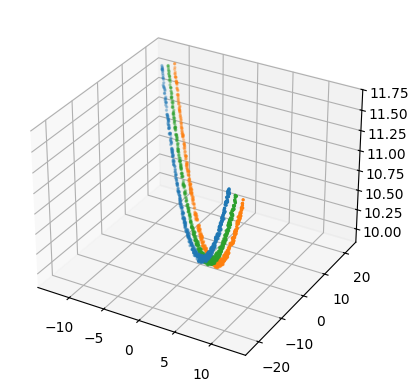

In [22]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

# Medium - DBScan Clustering

In [23]:
# numpy array
coordinates_medium = lidar_data_df_medium[["x", "y", "z"]].values
print(coordinates_medium)

[[  8.92709104 -17.27170487   7.72455081]
 [ -0.51460285   3.71330132   6.60466739]
 [  6.14180642 -11.18833806  10.43859675]
 ...
 [  3.35515603  -8.01030698  10.20106081]
 [  1.36849341  -0.65532002   9.98307589]
 [  5.46552352 -11.91274029  10.49119338]]


In [41]:
import numpy as np
def generate_list(start, end, step):
    return np.round(np.arange(start, end, step), 4).tolist()

In [28]:
# clustering and no. of clusters 
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5]
eps_list = generate_list(0.7, 0.8, 0.005)
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_medium)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.7, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
For eps = 0.7, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
For eps = 0.71, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
For eps = 0.72, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.72, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.72, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.73, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.75, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8}
For eps = 0.77, Unique clusters: {0, 1, 2, 3, 4, 5, 6}
For eps = 0.78, Unique clusters: {0,

In [31]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
eps_list = [0.74]
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_medium)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


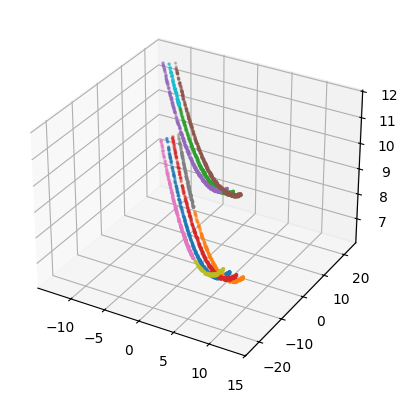

In [32]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates_medium[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

# Hard - DBScan Clustering

In [33]:
# numpy array
coordinates_hard = lidar_data_df_hard[["x", "y", "z"]].values
print(coordinates_medium)

[[  8.92709104 -17.27170487   7.72455081]
 [ -0.51460285   3.71330132   6.60466739]
 [  6.14180642 -11.18833806  10.43859675]
 ...
 [  3.35515603  -8.01030698  10.20106081]
 [  1.36849341  -0.65532002   9.98307589]
 [  5.46552352 -11.91274029  10.49119338]]


In [44]:
# clustering and no. of clusters 
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5]
#eps_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
eps_list = generate_list(0.75, 1, 0.005)
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_hard)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.75, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, -1}
For eps = 0.755, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, -1}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, -1}
For eps = 0.765, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}
For eps = 0.77, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}
For eps = 0.775, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}
For eps = 0.78, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2

In [42]:
eps_list = generate_list(0.75, 0.85, 0.005)
eps_list

[0.75,
 0.755,
 0.76,
 0.765,
 0.77,
 0.775,
 0.78,
 0.785,
 0.79,
 0.795,
 0.8,
 0.805,
 0.81,
 0.815,
 0.82,
 0.825,
 0.83,
 0.835,
 0.84,
 0.845]

In [51]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
eps_list = [0.77]
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_hard)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.77, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}


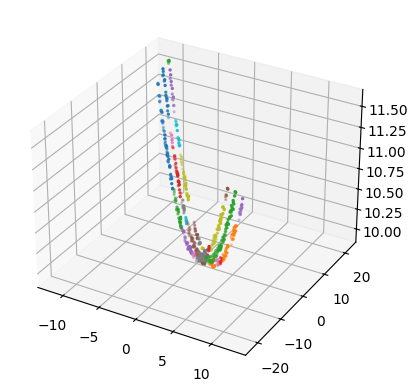

In [52]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates_hard[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

Tried eps values in the range (0–1) with step sizes of 0.01 and 0.001.
- Based on stable cluster point values, plotted the graph.
- worked well for the easy dataset.
- But for medium and hard datasets, even when eps values produced stable cluster counts, the visualized clusters were not accurate (overlap issues).

# Note:
It looks like the cluster is a big vague having the same line with multiple color, so whatever done might be wrong.  
Is it the angle at which drone captured data? probably overlapping wires?  
Makes sense to be honest, the wires are also no good U shaped, change the angle we view?  

Question: for a 3d data of cable wires if we want to view it in 2d what algo should be used in python scikit learn package?


# PCA

In [57]:
n_samples = lidar_data_df_easy.shape[0]
n_feature = lidar_data_df_easy.shape[1]
n_componets = min(n_samples, n_feature)
from sklearn.decomposition import PCA
points = lidar_data_df_easy[["x","y","z"]].values

pca = PCA(n_components=n_componets).fit(points)
projected = pca.transform(points)

I think the PCA is having 3d vector which shows along different axes?

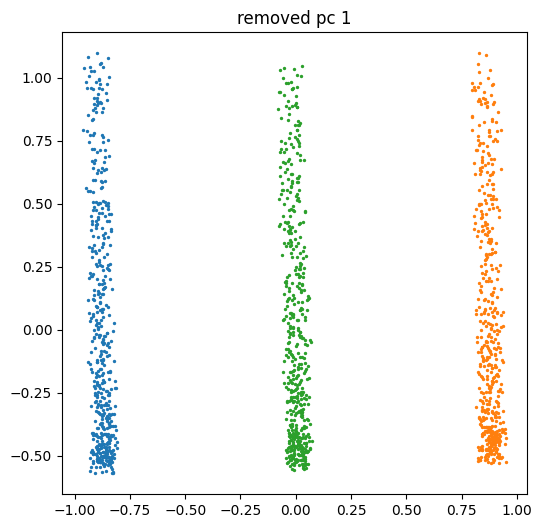

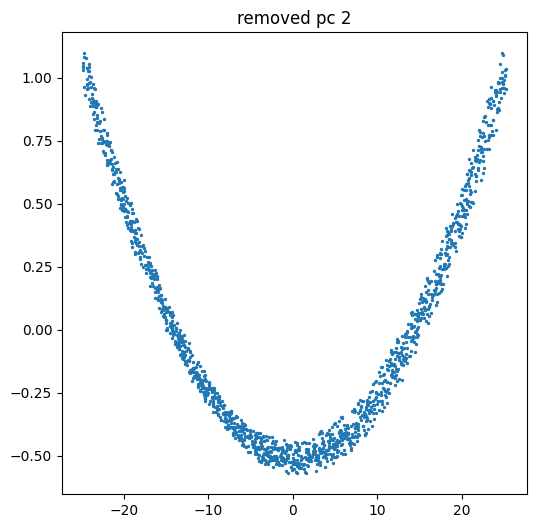

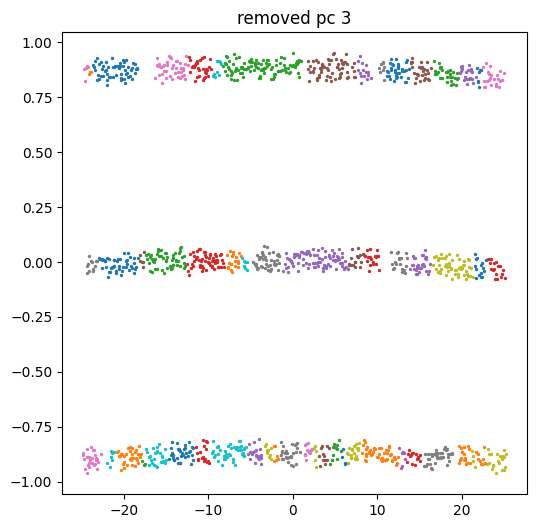

In [64]:
for i in range(0,3):
    reduced = np.delete(projected, i , axis = 1)
    labels = DBSCAN(eps = 0.3, min_samples = 5).fit_predict(reduced)
    plt.figure(figsize=(6,6))
    for cluster_id in set(labels):
        if cluster_id == -1:
            continue
        cluster_points = reduced[labels == cluster_id]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=2, label = f"cluster {cluster_id}")
        plt.title(f"removed pc {i+1}")
        
    plt.savefig("images/cluster_list_visualization.png")
    # break

I can find teh clear separable clusters from plot 1, but in real pipeline what can i do to find it automatically? we dont need to look into the graph manually every time isnt it

In [69]:
remove_axis = np.argmax((pca.explained_variance_ratio_))
actual_reduced = np.delete(projected, remove_axis, axis=1)
actual_reduced

array([[-0.86966549,  0.05222722],
       [-0.90130488,  0.40490854],
       [ 0.91877496, -0.41414808],
       ...,
       [ 0.79611622,  0.79078716],
       [ 0.9447582 , -0.39286749],
       [ 0.88652219,  0.57884949]])

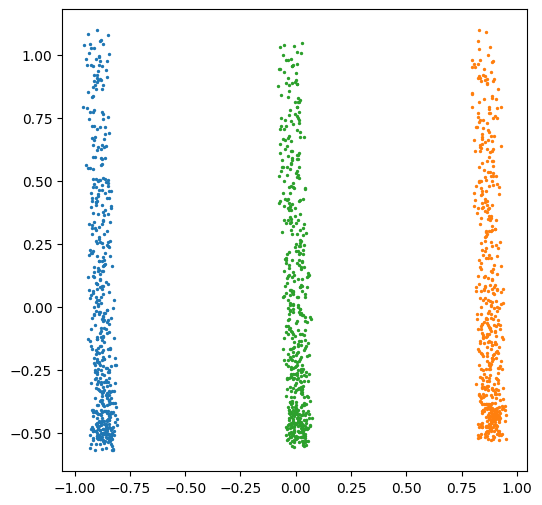

In [71]:
labels = DBSCAN(eps = 0.3, min_samples = 5).fit_predict(actual_reduced)
plt.figure(figsize=(6,6))
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = actual_reduced[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=2, label = f"cluster {cluster_id}")
    # plt.title(f"removed pc {i+1}")
    
plt.savefig("images/cluster_list_visualization.png")

First lets assign the clusters to the points

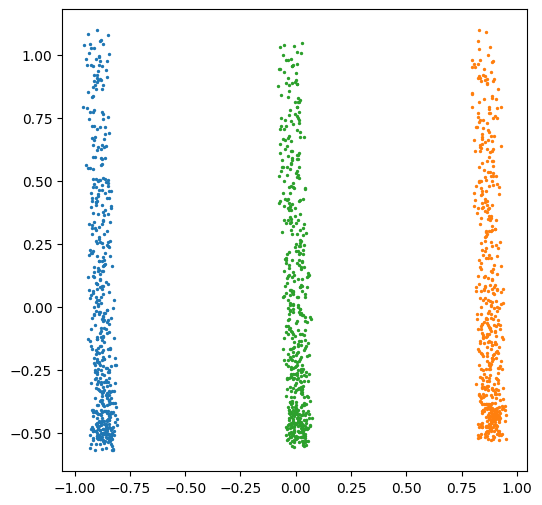

In [ ]:
from scipy.optimize import curver_fit

labels = DBSCAN(eps = 0.3, min_samples = 5).fit_predict(actual_reduced)
# plt.figure(figsize=(6,6))
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = actual_reduced[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=2, label = f"cluster {cluster_id}")
    # plt.title(f"removed pc {i+1}")
    pts = points[labels == cluster_id]
# plt.savefig("images/cluster_list_visualization.png")

In [73]:
pts

array([[  5.92449447, -10.9749597 ,  10.34250123],
       [ -7.06287274,  12.85066423,  10.55799733],
       [  2.1889814 ,  -4.04699069,  10.09745578],
       ...,
       [  8.21516587, -14.96419738,  10.72106363],
       [ 10.56302813, -19.27755949,  11.24058302],
       [ -8.35244344,  15.35507594,  10.74103111]])

# 3D->2D

Converting 3D->2D

In [ ]:
# first cluster details
cluster_0 = coordinates[labels == 0]
print(cluster_0.shape)
print(cluster_0[:5])

In [ ]:
# cluster visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
blank_canvas.scatter(cluster_0[:, 0], cluster_0[:, 1], cluster_0[:, 2], s=3)
plt.show()

In [ ]:
# 3D to 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
transformed_coordinates = pca.fit_transform(cluster_0)
flatten_2d_points = transformed_coordinates[:, :2]
print(flatten_2d_points[:5])
print("PCA components = ")
print(pca.components_)

In [ ]:
#first cluster visualization - transformed to 2D
blank_canvas = plt.figure().add_subplot(111)
blank_canvas.scatter(flatten_2d_points[:, 0], flatten_2d_points[:, 1], s=3)
plt.show()

Curve best fit for the first cluster

In [ ]:
# Catanary curve equation
import numpy as np
def curve_equation(x, x0, y0, c):
    return y0 + c * (np.cosh((x - x0) / c) - 1)


In [ ]:
from scipy.optimize import curve_fit
x_data = flatten_2d_points[:, 0]
y_data= flatten_2d_points[:, 1]
initial_assumption_values = [np.mean(x_data), np.min(y_data), 100]
params, covariance = curve_fit(curve_equation, x_data, y_data, p0 = initial_assumption_values)
x0, y0, c = params
print("x0 = ", float(x0))
print("y0 = ", float(y0))
print("c = ", float(c))